<a href="https://colab.research.google.com/github/Hemajeyan/DHANANJEYAN-S/blob/main/Tabular_Classification_%26_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import Required Libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models & Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Built-in dataset for regression
from sklearn.datasets import fetch_california_housing


In [3]:
# Load Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')
df_class = titanic.copy()

print("✅ Titanic dataset loaded successfully!\n")

# Quick view of dataset
print(df_class.head())

# Basic info about the dataset
print("\nDataset Info:")
print(df_class.info())

# Check missing values
print("\nMissing values per column:")
print(df_class.isnull().sum())

# Drop columns not useful for prediction
df_class.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1, inplace=True)

# Fill missing values for age with median
df_class['age'].fillna(df_class['age'].median(), inplace=True)

# Fill missing values for embarked with most frequent value
df_class['embarked'].fillna(df_class['embarked'].mode()[0], inplace=True)

# Convert categorical variables into dummy/indicator variables
df_class = pd.get_dummies(df_class, columns=['sex', 'embarked'], drop_first=True)

# Features and target
X_class = df_class.drop('survived', axis=1)
y_class = df_class['survived']

# Train-test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print("\n✅ Data preprocessing for classification is complete!")
print(f"Training samples: {Xc_train.shape[0]}, Testing samples: {Xc_test.shape[0]}")

✅ Titanic dataset loaded successfully!

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------     

/tmp/ipython-input-3315213406.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_class['age'].fillna(df_class['age'].median(), inplace=True)
/tmp/ipython-input-3315213406.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac


🔹 Random Forest Classifier Results:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179

✅ Accuracy: 0.82

🔹 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

✅ Accuracy: 0.80


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


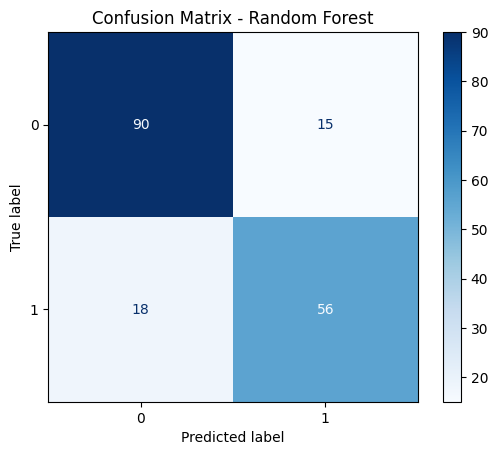

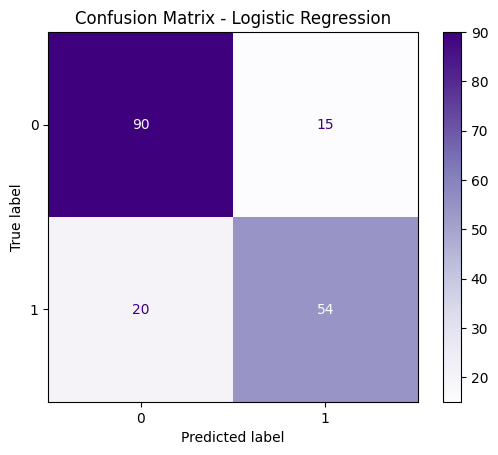

In [4]:
# --- Random Forest Classifier ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(Xc_train, yc_train)
y_pred_rf = rf_clf.predict(Xc_test)

print("\n🔹 Random Forest Classifier Results:")
print(classification_report(yc_test, y_pred_rf))
print(f"✅ Accuracy: {accuracy_score(yc_test, y_pred_rf):.2f}")

# --- Logistic Regression ---
log_clf = LogisticRegression(max_iter=200, random_state=42)
log_clf.fit(Xc_train, yc_train)
y_pred_log = log_clf.predict(Xc_test)

print("\n🔹 Logistic Regression Results:")
print(classification_report(yc_test, y_pred_log))
print(f"✅ Accuracy: {accuracy_score(yc_test, y_pred_log):.2f}")

# --- Confusion Matrix for Random Forest ---
cm_rf = confusion_matrix(yc_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_clf.classes_)
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# --- Confusion Matrix for Logistic Regression ---
cm_log = confusion_matrix(yc_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_clf.classes_)
disp_log.plot(cmap="Purples")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


✅ California Housing dataset loaded successfully!
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

Missing values: 0

🔹 Random Forest Regressor Results:
MAE:  0.33
MSE:  0.26
RMSE: 0.51
R²:   0.81

🔹 Linear Regression Results:
MAE:  0.53
MSE:  0.56
RMSE: 0.75
R²:   0.58


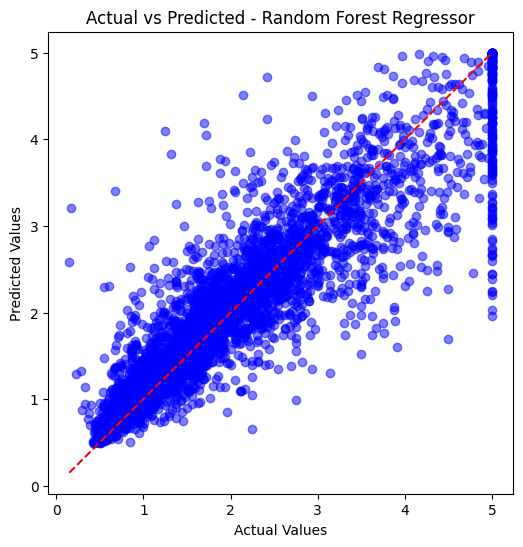

In [5]:
# --- Load California Housing Dataset ---
housing = fetch_california_housing()
df_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
df_reg['target'] = housing.target

print("✅ California Housing dataset loaded successfully!")
print(df_reg.head())

# --- Check for missing values ---
print("\nMissing values:", df_reg.isnull().sum().sum())

# --- Features & Target ---
X_reg = df_reg.drop('target', axis=1)
y_reg = df_reg['target']

# --- Feature Scaling ---
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# --- Train-Test Split ---
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

# --- Random Forest Regressor ---
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(Xr_train, yr_train)
y_pred_rf_reg = rf_reg.predict(Xr_test)

# --- Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)
y_pred_lin_reg = lin_reg.predict(Xr_test)

# --- Evaluation Function ---
def evaluate_regression(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name} Results:")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"MSE:  {mean_squared_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R²:   {r2_score(y_true, y_pred):.2f}")

# --- Evaluate Both Models ---
evaluate_regression(yr_test, y_pred_rf_reg, "Random Forest Regressor")
evaluate_regression(yr_test, y_pred_lin_reg, "Linear Regression")

# --- Scatter Plot: Actual vs Predicted (Random Forest) ---
plt.figure(figsize=(6,6))
plt.scatter(yr_test, y_pred_rf_reg, alpha=0.5, color='blue')
plt.plot([min(yr_test), max(yr_test)], [min(yr_test), max(yr_test)], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Random Forest Regressor")
plt.show()


✅ Titanic dataset loaded successfully!



/tmp/ipython-input-3746071582.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_class['age'].fillna(df_class['age'].median(), inplace=True)
/tmp/ipython-input-3746071582.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac


🔹 Random Forest Classifier Results:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179

✅ Accuracy: 0.82

🔹 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

✅ Accuracy: 0.80


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


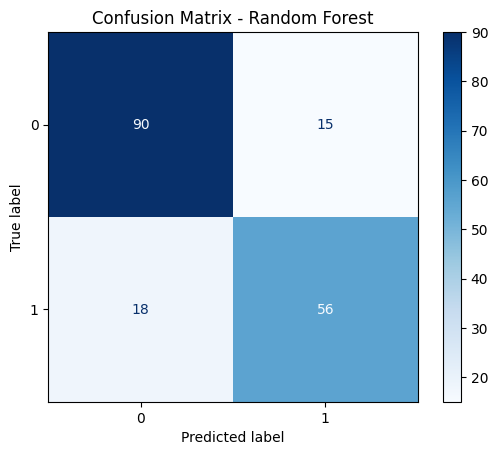

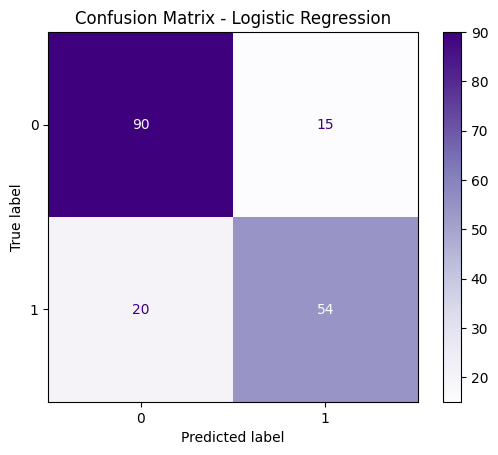


✅ California Housing dataset loaded successfully!

🔹 Random Forest Regressor Results:
MAE:  0.33
MSE:  0.26
RMSE: 0.51
R²:   0.81

🔹 Linear Regression Results:
MAE:  0.53
MSE:  0.56
RMSE: 0.75
R²:   0.58


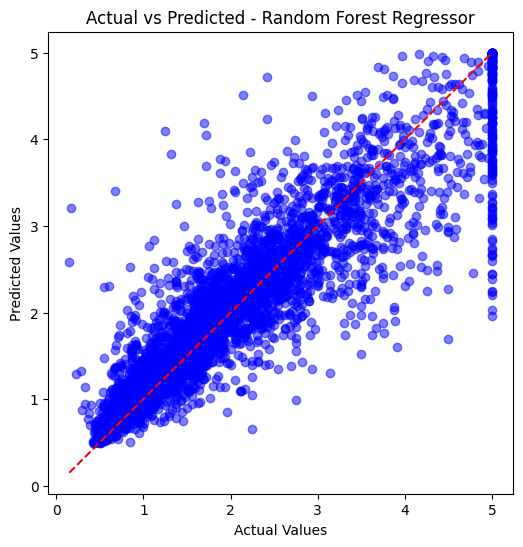


🎯 PROJECT COMPLETE: Classification & Regression models trained, evaluated, and visualized!


In [7]:
# =====================================================
# 📊 TABULAR CLASSIFICATION & REGRESSION PROJECT
# =====================================================

# -----------------------------------
# STEP 1: Import Libraries
# -----------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import fetch_california_housing

# =====================================================
# PART 1: CLASSIFICATION - TITANIC DATASET
# =====================================================

# Load Titanic Dataset
titanic = sns.load_dataset('titanic')
df_class = titanic.copy()
print("✅ Titanic dataset loaded successfully!\n")

# Drop irrelevant columns
df_class.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1, inplace=True)

# Handle missing values
df_class['age'].fillna(df_class['age'].median(), inplace=True)
df_class['embarked'].fillna(df_class['embarked'].mode()[0], inplace=True)

# Encode categorical variables
df_class = pd.get_dummies(df_class, columns=['sex', 'embarked'], drop_first=True)

# Define features & target
X_class = df_class.drop('survived', axis=1)
y_class = df_class['survived']

# Train-test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# --- Random Forest Classifier ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(Xc_train, yc_train)
y_pred_rf = rf_clf.predict(Xc_test)

print("\n🔹 Random Forest Classifier Results:")
print(classification_report(yc_test, y_pred_rf))
print(f"✅ Accuracy: {accuracy_score(yc_test, y_pred_rf):.2f}")

# --- Logistic Regression ---
log_clf = LogisticRegression(max_iter=200, random_state=42)
log_clf.fit(Xc_train, yc_train)
y_pred_log = log_clf.predict(Xc_test)

print("\n🔹 Logistic Regression Results:")
print(classification_report(yc_test, y_pred_log))
print(f"✅ Accuracy: {accuracy_score(yc_test, y_pred_log):.2f}")

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(yc_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_clf.classes_)
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Confusion Matrix - Logistic Regression
cm_log = confusion_matrix(yc_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_clf.classes_)
disp_log.plot(cmap="Purples")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# =====================================================
# PART 2: REGRESSION - CALIFORNIA HOUSING DATASET
# =====================================================

# Load California Housing Dataset
housing = fetch_california_housing()
df_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
df_reg['target'] = housing.target
print("\n✅ California Housing dataset loaded successfully!")

# Features & target
X_reg = df_reg.drop('target', axis=1)
y_reg = df_reg['target']

# Feature scaling
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Train-test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

# --- Random Forest Regressor ---
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(Xr_train, yr_train)
y_pred_rf_reg = rf_reg.predict(Xr_test)

# --- Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)
y_pred_lin_reg = lin_reg.predict(Xr_test)

# Evaluation function
def evaluate_regression(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name} Results:")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"MSE:  {mean_squared_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R²:   {r2_score(y_true, y_pred):.2f}")

# Evaluate models
evaluate_regression(yr_test, y_pred_rf_reg, "Random Forest Regressor")
evaluate_regression(yr_test, y_pred_lin_reg, "Linear Regression")

# Scatter plot - Random Forest Predictions
plt.figure(figsize=(6,6))
plt.scatter(yr_test, y_pred_rf_reg, alpha=0.5, color='blue')
plt.plot([min(yr_test), max(yr_test)], [min(yr_test), max(yr_test)], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Random Forest Regressor")
plt.show()

print("\n🎯 PROJECT COMPLETE: Classification & Regression models trained, evaluated, and visualized!")

✅ Titanic dataset loaded successfully!



/tmp/ipython-input-1763241037.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_class['age'].fillna(df_class['age'].median(), inplace=True)
/tmp/ipython-input-1763241037.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac


🔹 Random Forest Classifier Results:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179

✅ Accuracy: 0.82

🔹 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

✅ Accuracy: 0.80


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


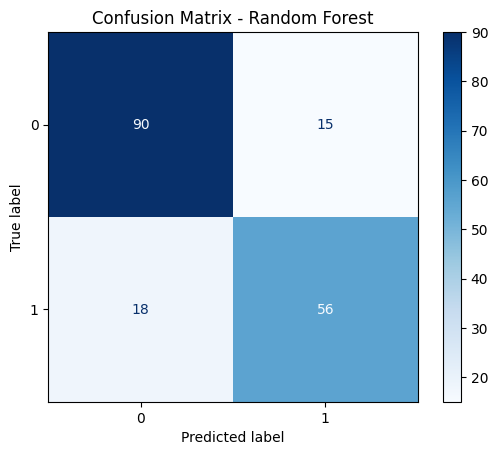

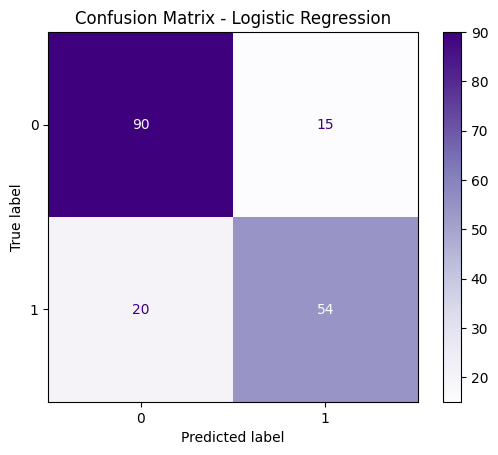

/tmp/ipython-input-1763241037.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_clf, y=features_clf, palette="viridis")


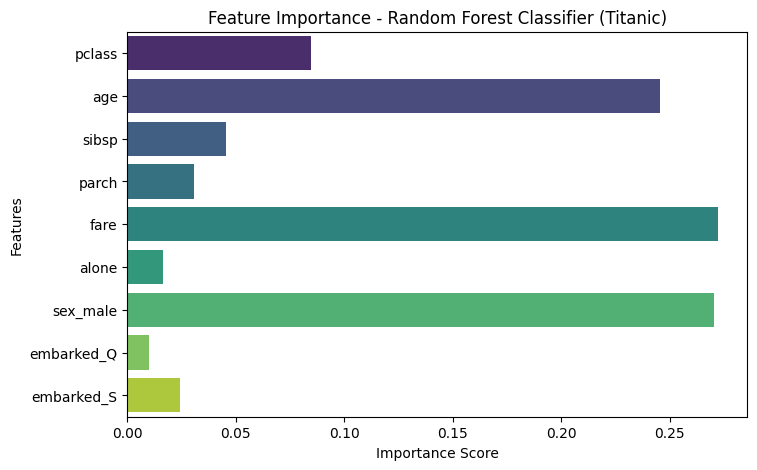


✅ California Housing dataset loaded successfully!

🔹 Random Forest Regressor Results:
MAE:  0.33
MSE:  0.26
RMSE: 0.51
R²:   0.81

🔹 Linear Regression Results:
MAE:  0.53
MSE:  0.56
RMSE: 0.75
R²:   0.58


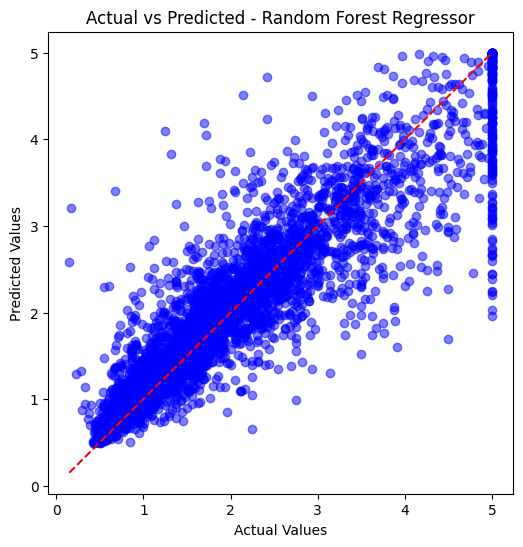

/tmp/ipython-input-1763241037.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_reg, y=features_reg, palette="coolwarm")


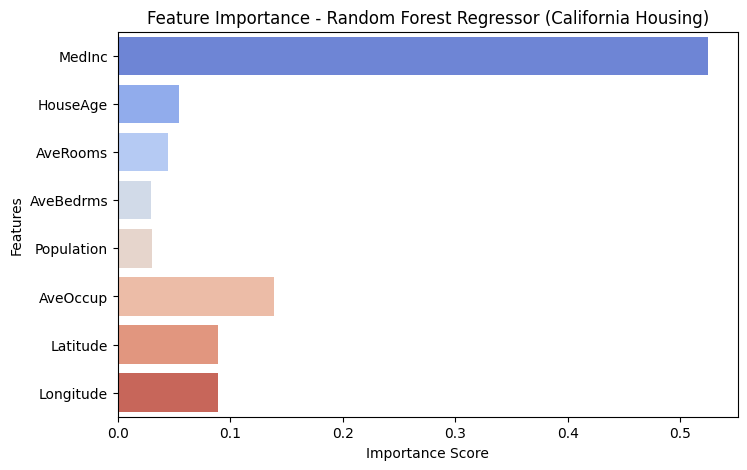

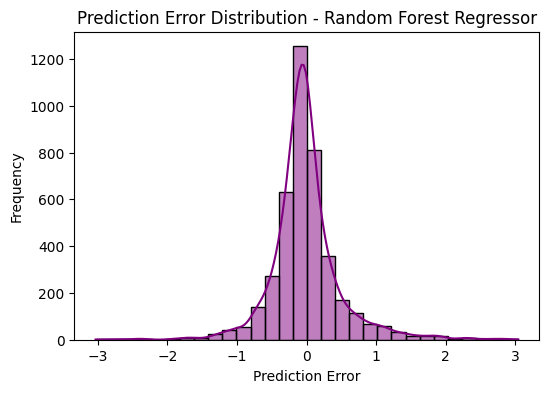


🎯 PROJECT COMPLETE: Classification & Regression models trained, evaluated, and visualized!


In [9]:
# =====================================================
# 📊 TABULAR CLASSIFICATION & REGRESSION PROJECT
# =====================================================

# -----------------------------------
# STEP 1: Import Libraries
# -----------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import fetch_california_housing

# =====================================================
# PART 1: CLASSIFICATION - TITANIC DATASET
# =====================================================

# Load Titanic Dataset
titanic = sns.load_dataset('titanic')
df_class = titanic.copy()
print("✅ Titanic dataset loaded successfully!\n")

# Drop irrelevant columns
df_class.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1, inplace=True)

# Handle missing values
df_class['age'].fillna(df_class['age'].median(), inplace=True)
df_class['embarked'].fillna(df_class['embarked'].mode()[0], inplace=True)

# Encode categorical variables
df_class = pd.get_dummies(df_class, columns=['sex', 'embarked'], drop_first=True)

# Define features & target
X_class = df_class.drop('survived', axis=1)
y_class = df_class['survived']

# Train-test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# --- Random Forest Classifier ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(Xc_train, yc_train)
y_pred_rf = rf_clf.predict(Xc_test)

print("\n🔹 Random Forest Classifier Results:")
print(classification_report(yc_test, y_pred_rf))
print(f"✅ Accuracy: {accuracy_score(yc_test, y_pred_rf):.2f}")

# --- Logistic Regression ---
log_clf = LogisticRegression(max_iter=200, random_state=42)
log_clf.fit(Xc_train, yc_train)
y_pred_log = log_clf.predict(Xc_test)

print("\n🔹 Logistic Regression Results:")
print(classification_report(yc_test, y_pred_log))
print(f"✅ Accuracy: {accuracy_score(yc_test, y_pred_log):.2f}")

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(yc_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_clf.classes_)
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Confusion Matrix - Logistic Regression
cm_log = confusion_matrix(yc_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_clf.classes_)
disp_log.plot(cmap="Purples")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# --- Feature Importance - Classification ---
importances_clf = rf_clf.feature_importances_
features_clf = X_class.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances_clf, y=features_clf, palette="viridis")
plt.title("Feature Importance - Random Forest Classifier (Titanic)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# =====================================================
# PART 2: REGRESSION - CALIFORNIA HOUSING DATASET
# =====================================================

# Load California Housing Dataset
housing = fetch_california_housing()
df_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
df_reg['target'] = housing.target
print("\n✅ California Housing dataset loaded successfully!")

# Features & target
X_reg = df_reg.drop('target', axis=1)
y_reg = df_reg['target']

# Feature scaling
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Train-test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

# --- Random Forest Regressor ---
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(Xr_train, yr_train)
y_pred_rf_reg = rf_reg.predict(Xr_test)

# --- Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)
y_pred_lin_reg = lin_reg.predict(Xr_test)

# Evaluation function
def evaluate_regression(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name} Results:")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"MSE:  {mean_squared_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R²:   {r2_score(y_true, y_pred):.2f}")

# Evaluate models
evaluate_regression(yr_test, y_pred_rf_reg, "Random Forest Regressor")
evaluate_regression(yr_test, y_pred_lin_reg, "Linear Regression")

# Scatter plot - Random Forest Predictions
plt.figure(figsize=(6,6))
plt.scatter(yr_test, y_pred_rf_reg, alpha=0.5, color='blue')
plt.plot([min(yr_test), max(yr_test)], [min(yr_test), max(yr_test)], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Random Forest Regressor")
plt.show()

# --- Feature Importance - Regression ---
importances_reg = rf_reg.feature_importances_
features_reg = X_reg.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances_reg, y=features_reg, palette="coolwarm")
plt.title("Feature Importance - Random Forest Regressor (California Housing)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# --- Prediction Error Distribution - Regression ---
errors = yr_test - y_pred_rf_reg
plt.figure(figsize=(6, 4))
sns.histplot(errors, kde=True, color='purple', bins=30)
plt.title("Prediction Error Distribution - Random Forest Regressor")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

print("\n🎯 PROJECT COMPLETE: Classification & Regression models trained, evaluated, and visualized!")